# RQ1: Segment Users into Behavioral Types
**Goal:** Cluster Yambda users into interpretable behavioral archetypes — *explorers*, *replayers*, *curators*— using hand-crafted behavioral features and multiple clustering algorithms.

**Task type:** Clustering / representation learning  
**Algorithms:** K-Means, Hierarchical (Ward), HDBSCAN, GMM  
**Evaluation:** Silhouette, Davies–Bouldin, stability across seeds, feature interpretability, downstream prediction of organic rate / skip rate

## 0. Setup

In [1]:
!pip -q install duckdb hdbscan scikit-learn matplotlib seaborn

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from scipy.cluster.hierarchy import dendrogram, linkage
import hdbscan

SEED = 42
np.random.seed(SEED)

DATA = 'hf_cache_yambda/flat/500m/multi_event.parquet'
con = duckdb.connect()
print('DuckDB ready')

DuckDB ready


In [3]:
import os
import duckdb
from huggingface_hub import hf_hub_download

local_path = hf_hub_download(
    repo_id="yandex/yambda",
    repo_type="dataset",
    filename="flat/500m/multi_event.parquet",
    local_dir="hf_cache_yambda",   # optional: puts a local copy here
)

DATA = local_path
con = duckdb.connect()
con.execute("PRAGMA threads=8")
print("DuckDB ready")
print(DATA)

flat/500m/multi_event.parquet:   0%|          | 0.00/3.84G [00:00<?, ?B/s]

DuckDB ready
hf_cache_yambda/flat/500m/multi_event.parquet


## 1. Feature Engineering

We derive two groups of per-user features:

| Group | Features | Captures |
|---|---|---|
| **Activity** | `events_per_day`, `listens_per_day`, `n_sessions`, `n_items`, `listens_per_session_med` | Engagement level |
| **Engagement quality** | `skip_rate_mean`, `full_rate_mean` | How deeply users listen |
| **Context** | `organic_share` | Self-directed vs algorithmic listening |
| **Repetition** | `repeat_session_rate`, `repeat_event_rate_mean`, `imm_repeat_rate_mean` | Replay / exploitation tendency |
| **Catalog breadth** | `catalog_breadth` (`n_items / n_listens_total`), `n_unique_items_per_session_med`, `item_entropy` | Exploration width |
| **Explicit feedback** | `rate_like` , `rate_unlike`, `rate_dislike`, `rate_undislike` | Active taste curation |

Heavy-tailed count features will be log-transformed before clustering.  
**Note on feedback rates:** `rate_like` carries the strongest curation signal — it is highest-volume and unambiguous. `rate_unlike` / `rate_undislike` are reversal events (sparse, noisy) but retained as they distinguish active curators from passive listeners.

In [3]:
# ── 1a. User-level activity + feedback from ALL events ─────────────────────
print('Computing user activity features from all events...')
user_activity = con.execute(f"""
  SELECT
    uid,
    COUNT(*)                                                          AS n_events,
    COUNT(DISTINCT item_id)                                           AS n_items,
    AVG(is_organic)                                                   AS organic_share,
    (MAX(timestamp) - MIN(timestamp)) * 5.0 / 86400.0                AS t_span_days,
    SUM(CASE WHEN event_type='listen'    THEN 1 ELSE 0 END)          AS n_listens,
    -- Explicit feedback counts (like is highest-volume and most reliable)
    SUM(CASE WHEN event_type='like'      THEN 1 ELSE 0 END)          AS n_likes,
    SUM(CASE WHEN event_type='unlike'    THEN 1 ELSE 0 END)          AS n_unlikes,
    SUM(CASE WHEN event_type='dislike'   THEN 1 ELSE 0 END)          AS n_dislikes,
    SUM(CASE WHEN event_type='undislike' THEN 1 ELSE 0 END)          AS n_undislikes
  FROM read_parquet('{DATA}')
  GROUP BY uid
""").df()

# Derived rates — denominator is n_events to keep all rates on the same scale.
# rate_like is listed first: highest volume, cleanest positive intent signal.
# rate_unlike / rate_undislike are reversals — sparse but informative for curators.
user_activity['events_per_day']    = user_activity['n_events']    / user_activity['t_span_days'].clip(lower=1/86400)
user_activity['listens_per_day']   = user_activity['n_listens']   / user_activity['t_span_days'].clip(lower=1/86400)
user_activity['rate_like']         = user_activity['n_likes']     / user_activity['n_events']
user_activity['rate_unlike']       = user_activity['n_unlikes']   / user_activity['n_events']
user_activity['rate_dislike']      = user_activity['n_dislikes']  / user_activity['n_events']
user_activity['rate_undislike']    = user_activity['n_undislikes'] / user_activity['n_events']

print(f'  {len(user_activity):,} users')
user_activity.head(3)

Computing user activity features from all events...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  100,000 users


,uid,n_events,n_items,organic_share,t_span_days,n_listens,n_likes,n_unlikes,n_dislikes,n_undislikes,events_per_day,listens_per_day,rate_like,rate_unlike,rate_dislike,rate_undislike
0,3800,2513,1268,0.855551,1415.153356,2311.0,165.0,26.0,7.0,4.0,1.775779,1.633039,0.065659,0.010346,0.002786,0.001592
1,3960,1293,892,0.399072,385.073495,1285.0,0.0,0.0,7.0,1.0,3.357801,3.337025,0.000000,0.000000,0.005414,0.000773
2,4260,15744,1895,0.955285,1501.675637,14937.0,569.0,207.0,25.0,6.0,10.484288,9.946888,0.036141,0.013148,0.001588,0.000381


In [ ]:
# ── 1b. Session-level features from listens (30-min gap threshold) ──────────
print('Loading listens and sessionizing...')
listens = con.execute(f"""
  SELECT
    uid,
    timestamp * 5                                              AS t_sec,
    item_id,
    is_organic,
    LEAST(GREATEST(played_ratio_pct, 0), 100)                 AS played_clip,
    track_length_seconds
  FROM read_parquet('{DATA}')
  WHERE event_type = 'listen'
  ORDER BY uid, timestamp
""").df()

print(f'  {len(listens):,} listen events')

# Derive skip / full flags
listens['skip'] = (listens['played_clip'] < 20).astype('int8')
listens['full'] = (listens['played_clip'] >= 95).astype('int8')

# Sessionize: new session when gap > 30 min
listens = listens.sort_values(['uid', 't_sec'])
gap = listens.groupby('uid')['t_sec'].diff().fillna(0)
listens['new_sess'] = (gap > 1800).astype('int8')
listens['session_id'] = listens.groupby('uid')['new_sess'].cumsum()

# Immediate repeats
listens['prev_item'] = listens.groupby(['uid', 'session_id'])['item_id'].shift(1)
listens['imm_repeat'] = (listens['item_id'] == listens['prev_item']).astype('int8')

# Session-level aggregates
sess = listens.groupby(['uid', 'session_id']).agg(
    n_listens=('item_id', 'size'),
    n_unique=('item_id', 'nunique'),
    skip_rate=('skip', 'mean'),
    full_rate=('full', 'mean'),
    imm_repeat_rate=('imm_repeat', 'mean'),
).reset_index()
sess['has_repeat'] = (sess['n_unique'] < sess['n_listens']).astype('int8')
sess['repeat_event_rate'] = (sess['n_listens'] - sess['n_unique']) / sess['n_listens'].clip(lower=1)

# User-level aggregates from sessions
user_from_sess = sess.groupby('uid').agg(
    n_sessions=('n_listens', 'size'),
    listens_per_session_med=('n_listens', 'median'),
    n_unique_items_per_session_med=('n_unique', 'median'),   # catalog breadth within sessions
    skip_rate_med=('skip_rate', 'median'),
    full_rate_med=('full_rate', 'median'),
    repeat_session_rate=('has_repeat', 'median'),
    repeat_event_rate_med=('repeat_event_rate', 'median'),
    imm_repeat_rate_med=('imm_repeat_rate', 'median'),
).reset_index()

print(f'  {len(user_from_sess):,} users with session data')
user_from_sess.head(3)

Loading listens and sessionizing...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  466,512,103 listen events


In [4]:
con.execute("PRAGMA threads=8")

print('Loading listens and sessionizing...')

con.execute(f"""
CREATE OR REPLACE TEMP TABLE listens AS
WITH base AS (
  SELECT
    uid,
    timestamp * 5 AS t_sec,
    item_id,
    is_organic,
    LEAST(GREATEST(played_ratio_pct, 0), 100) AS played_clip,
    track_length_seconds
  FROM read_parquet('{DATA}')
  WHERE event_type = 'listen'
),
sessionized AS (
  SELECT
    *,
    CASE
      WHEN LAG(t_sec) OVER (PARTITION BY uid ORDER BY t_sec) IS NULL THEN 0
      WHEN t_sec - LAG(t_sec) OVER (PARTITION BY uid ORDER BY t_sec) > 1800 THEN 1
      ELSE 0
    END AS new_sess
  FROM base
),
with_session_id AS (
  SELECT
    *,
    SUM(new_sess) OVER (
      PARTITION BY uid
      ORDER BY t_sec
      ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS session_id
  FROM sessionized
)
SELECT
  uid,
  t_sec,
  item_id,
  is_organic,
  played_clip,
  track_length_seconds,
  CASE WHEN played_clip < 20 THEN 1 ELSE 0 END AS skip,
  CASE WHEN played_clip >= 95 THEN 1 ELSE 0 END AS full_play,
  new_sess,
  session_id,
  LAG(item_id) OVER (PARTITION BY uid, session_id ORDER BY t_sec) AS prev_item,
  CASE
    WHEN item_id = LAG(item_id) OVER (PARTITION BY uid, session_id ORDER BY t_sec) THEN 1
    ELSE 0
  END AS imm_repeat
FROM with_session_id
""")

n_listens = con.execute("SELECT COUNT(*) FROM listens").fetchone()[0]
print(f'  {n_listens:,} listen events')

con.execute("""
CREATE OR REPLACE TEMP TABLE sess AS
SELECT
  uid,
  session_id,
  COUNT(*) AS n_listens,
  COUNT(DISTINCT item_id) AS n_unique,
  AVG(skip) AS skip_rate,
  AVG(full_play) AS full_rate,
  AVG(imm_repeat) AS imm_repeat_rate,
  CASE
    WHEN COUNT(DISTINCT item_id) < COUNT(*) THEN 1
    ELSE 0
  END AS has_repeat,
  CASE
    WHEN COUNT(*) > 0 THEN (COUNT(*) - COUNT(DISTINCT item_id)) * 1.0 / COUNT(*)
    ELSE 0
  END AS repeat_event_rate
FROM listens
GROUP BY uid, session_id
""")

user_from_sess = con.execute("""
SELECT
  uid,
  COUNT(*) AS n_sessions,
  MEDIAN(n_listens) AS listens_per_session_med,
  MEDIAN(n_unique) AS n_unique_items_per_session_med,
  MEDIAN(skip_rate) AS skip_rate_med,
  MEDIAN(full_rate) AS full_rate_med,
  MEDIAN(has_repeat) AS repeat_session_rate,
  MEDIAN(repeat_event_rate) AS repeat_event_rate_med,
  MEDIAN(imm_repeat_rate) AS imm_repeat_rate_med
FROM sess
GROUP BY uid
""").df()

listens = con.table("listens")
sess = con.table("sess")

print(f'  {len(user_from_sess):,} users with session data')
user_from_sess.head(3)

Loading listens and sessionizing...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  466,512,103 listen events


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  92,085 users with session data


,uid,n_sessions,listens_per_session_med,n_unique_items_per_session_med,skip_rate_med,full_rate_med,repeat_session_rate,repeat_event_rate_med,imm_repeat_rate_med
0,8490,1521,7.0,6.0,0.088235,0.7,0.0,0.0,0.0
1,8540,811,4.0,4.0,0.000000,1.0,0.0,0.0,0.0
2,10980,743,3.0,3.0,0.055556,0.6,0.0,0.0,0.0


In [10]:
# ── 1c. Item diversity (Shannon entropy of item distribution per user) ───────
print('Computing item diversity (entropy)...')

item_counts = listens.groupby(['uid', 'item_id']).size().reset_index(name='cnt')
totals = item_counts.groupby('uid')['cnt'].transform('sum')
item_counts['p'] = item_counts['cnt'] / totals
entropy = item_counts.groupby('uid').apply(lambda g: -np.sum(g['p'] * np.log2(g['p'] + 1e-12))).reset_index()
entropy.columns = ['uid', 'item_entropy']

print(f'  entropy computed for {len(entropy):,} users')

Computing item diversity (entropy)...


AttributeError: This relation does not contain a column by the name of 'groupby'

In [5]:
# ── 1c. Item diversity (Shannon entropy of item distribution per user) ───────
print('Computing item diversity (entropy)...')

entropy = con.execute("""
WITH item_counts AS (
  SELECT
    uid,
    item_id,
    COUNT(*) AS cnt
  FROM listens
  GROUP BY uid, item_id
),
totals AS (
  SELECT
    uid,
    SUM(cnt) AS total_cnt
  FROM item_counts
  GROUP BY uid
),
probs AS (
  SELECT
    i.uid,
    i.item_id,
    i.cnt,
    t.total_cnt,
    i.cnt * 1.0 / t.total_cnt AS p
  FROM item_counts i
  JOIN totals t USING (uid)
)
SELECT
  uid,
  -SUM(p * LOG2(p + 1e-12)) AS item_entropy
FROM probs
GROUP BY uid
ORDER BY uid
""").df()

print(f'  entropy computed for {len(entropy):,} users')
entropy.head(3)

Computing item diversity (entropy)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  entropy computed for 92,085 users


,uid,item_entropy
0,10,9.557743
1,20,6.277569
2,30,10.259979


In [6]:
# ── 1d. Merge into user_features ────────────────────────────────────────────
user_features = (
    user_activity
    .merge(user_from_sess, on='uid', how='inner')
    .merge(entropy,        on='uid', how='left')
)

# catalog_breadth: unique items relative to total listens.
# High → explorer (wide variety); Low → replayer (revisits same tracks).
# n_items comes from ALL events; n_listens is listen-only — use n_listens as denominator
# to keep it comparable to the session-level n_unique_items_per_session_med.
user_features['catalog_breadth'] = (
    user_features['n_items'] / user_features['n_listens'].clip(lower=1)
)

# Drop users with very few interactions (< 5 listens) — too noisy to cluster
user_features = user_features[user_features['n_listens'] >= 5].copy()

# Fill remaining NaNs (e.g. single-listen users missing imm_repeat)
user_features = user_features.fillna(0)

print(f'Final user_features: {user_features.shape}')
user_features.describe().T[['mean','std','min','50%','max']].round(3)

Final user_features: (92083, 26)


,mean,std,min,50%,max
uid,499355.059,288317.411,10.000,499050.000,1000000.000
n_events,5190.789,5587.723,11.000,3170.000,27736.000
n_items,1477.027,1319.991,1.000,1134.000,14555.000
organic_share,0.539,0.310,0.000,0.544,1.000
t_span_days,1138.520,466.437,9.016,1425.005,1504.626
n_listens,5066.213,5480.544,6.000,3075.000,27730.000
n_likes,82.415,190.563,0.000,22.000,18809.000
n_unlikes,29.620,121.561,0.000,3.000,12694.000
n_dislikes,10.048,80.035,0.000,1.000,6015.000
n_undislikes,2.493,51.458,0.000,0.000,10096.000


* high heterogeneity across users
* generally long user histories
* most users are listen-dominant, with relatively sparse explicit feedback
* replay exists, but for the typical user it is low
* users show substantial item diversity, which is good for segmentation

## 2. Feature Preparation

1. removes the most cluster-dominating scale features
2. keeps the style-defining features
3. adds a compact activity control feature instead of several overlapping volume variables

In [7]:
# ── 2a. Select and transform features (behavior-first version) ───────────────
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# fix / verify catalog_breadth
# If you intended catalog_breadth = n_items / n_listens, recompute it safely.
user_features = user_features.copy()
user_features["catalog_breadth"] = (
    user_features["n_items"] / user_features["n_listens"].clip(lower=1)
)

# combine sparse feedback signals into a more stable total feedback rate
user_features["feedback_rate"] = (
    user_features["rate_like"].fillna(0)
    + user_features["rate_unlike"].fillna(0)
    + user_features["rate_dislike"].fillna(0)
    + user_features["rate_undislike"].fillna(0)
)

# create one compact activity control instead of many raw size features
user_features["activity_level"] = np.log1p(
    user_features["listens_per_day"].fillna(0)
)

FEATURE_COLS = [
    # ── Compact activity control (keep only one) ──
    "activity_level",

    # ── Engagement quality ──
    "skip_rate_med",
    "full_rate_med",

    # ── Context ──
    "organic_share",

    # ── Repetition ──
    "repeat_session_rate",
    "repeat_event_rate_med",
    "imm_repeat_rate_med",

    # ── Exploration / diversity ──
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "item_entropy",

    # ── Explicit feedback ──
    "rate_like",
    "rate_unlike",
    "rate_dislike",
    "rate_undislike",
    "feedback_rate",
]

LOG_COLS = [
    "n_unique_items_per_session_med",   # still somewhat skewed
]

feat = user_features[FEATURE_COLS].copy()

# Fill missing values if any
feat = feat.fillna(feat.median(numeric_only=True))

# Winsorize to reduce extreme outlier influence
for c in feat.columns:
    lo, hi = feat[c].quantile([0.01, 0.99])
    feat[c] = feat[c].clip(lo, hi)

# Log-transform selected skewed columns
for c in LOG_COLS:
    feat[c] = np.log1p(feat[c])

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(feat)

print(f"Feature matrix shape: {X.shape}  ({len(FEATURE_COLS)} features × {len(feat):,} users)")
print("Features used:")
print(FEATURE_COLS)

Feature matrix shape: (92083, 15)  (15 features × 92,083 users)
Features used:
['activity_level', 'skip_rate_med', 'full_rate_med', 'organic_share', 'repeat_session_rate', 'repeat_event_rate_med', 'imm_repeat_rate_med', 'catalog_breadth', 'n_unique_items_per_session_med', 'item_entropy', 'rate_like', 'rate_unlike', 'rate_dislike', 'rate_undislike', 'feedback_rate']


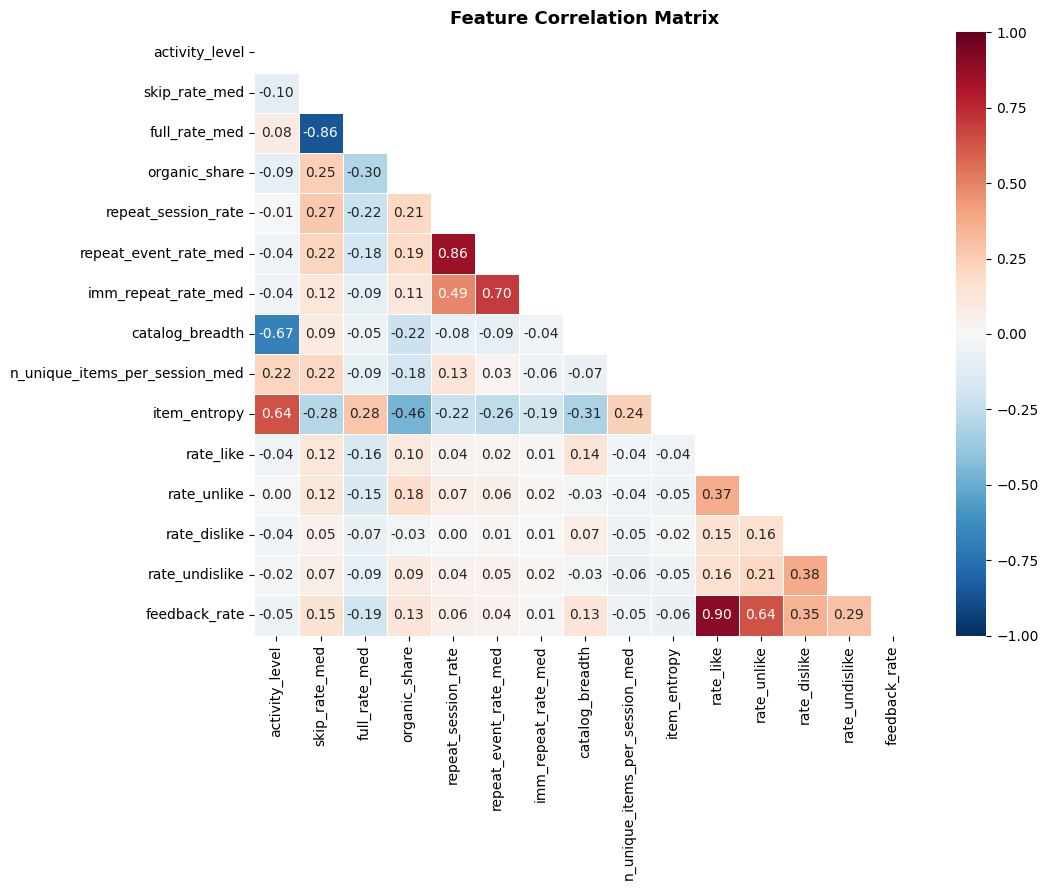

High-correlation pairs (|r| > 0.85):
  skip_rate_med  ↔  full_rate_med  : -0.858
  repeat_session_rate  ↔  repeat_event_rate_med  : 0.856
  rate_like  ↔  feedback_rate  : 0.903


In [8]:
# ── 2b. Correlation heatmap ──────────────────────────────────────────────────
corr = feat.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax,
            xticklabels=FEATURE_COLS, yticklabels=FEATURE_COLS)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.85)
high_corr = [
    (FEATURE_COLS[i], FEATURE_COLS[j], round(corr.iloc[i, j], 3))
    for i in range(len(FEATURE_COLS))
    for j in range(i+1, len(FEATURE_COLS))
    if abs(corr.iloc[i, j]) > 0.85
]
print('High-correlation pairs (|r| > 0.85):')
for a, b, r in high_corr:
    print(f'  {a}  ↔  {b}  : {r}')

Most features are not dangerously redundant, which is good for clustering. The two clear exceptions are:

* skip_rate_med vs full_rate_med = -0.861
* rate_like vs feedback_rate = 0.904

So for clustering, I would drop one from each pair.

In [9]:
FEATURE_COLS = [
    "activity_level",
    "skip_rate_med",
    "organic_share",
    "repeat_session_rate",
    "repeat_event_rate_med",
    "imm_repeat_rate_med",
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "item_entropy",
    "rate_like",
    "rate_unlike",
    "rate_dislike",
    "rate_undislike",
]

LOG_COLS = ["n_unique_items_per_session_med"]

feat = user_features[FEATURE_COLS].copy().fillna(user_features[FEATURE_COLS].median(numeric_only=True))

for c in LOG_COLS:
    feat[c] = np.log1p(feat[c])

scaler = StandardScaler()
X = scaler.fit_transform(feat)

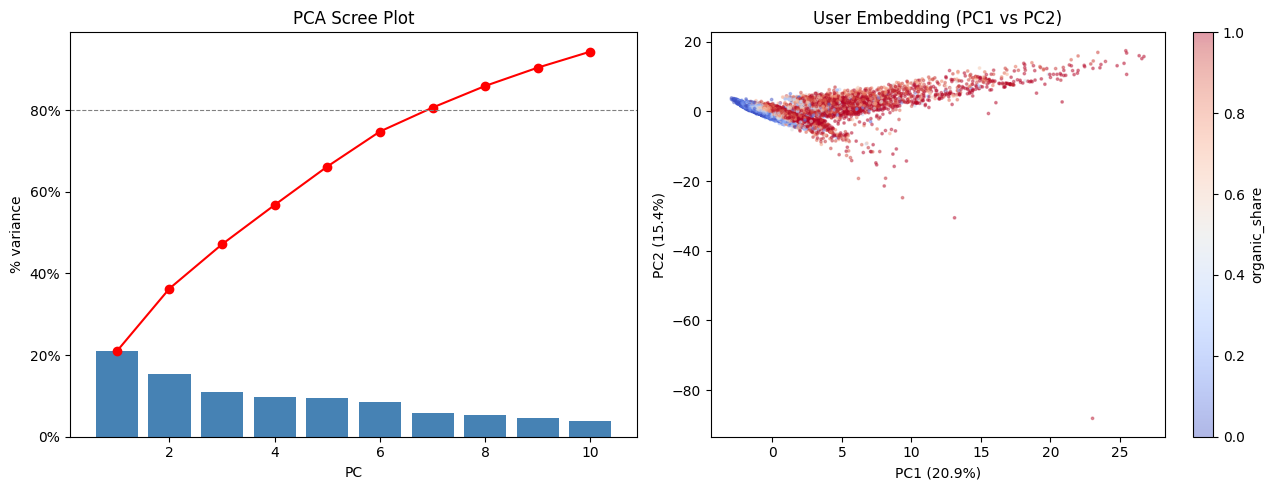


Top PC loadings:
                                  PC1    PC2    PC3
repeat_event_rate_med           0.478  0.350 -0.057
repeat_session_rate             0.412  0.307  0.099
imm_repeat_rate_med             0.385  0.290 -0.147
organic_share                   0.297 -0.060 -0.017
skip_rate_med                   0.265 -0.021  0.340
catalog_breadth                 0.108 -0.464  0.048
rate_unlike                     0.107 -0.125  0.368
rate_like                       0.102 -0.209  0.374
rate_undislike                  0.063 -0.082  0.397
rate_dislike                    0.046 -0.096  0.437
n_unique_items_per_session_med -0.092  0.238  0.374
activity_level                 -0.260  0.492  0.224
item_entropy                   -0.424  0.326  0.182


In [10]:
# ── 2c. PCA — 2-D projection for visualization ───────────────────────────────
pca = PCA(n_components=10, random_state=SEED)
X_pca_full = pca.fit_transform(X)
X_2d = X_pca_full[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
ev = pca.explained_variance_ratio_ * 100
axes[0].bar(range(1, len(ev)+1), ev, color='steelblue')
axes[0].plot(range(1, len(ev)+1), np.cumsum(ev), 'ro-')
axes[0].axhline(80, color='grey', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('PC'); axes[0].set_ylabel('% variance')
axes[0].set_title('PCA Scree Plot')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# 2-D projection coloured by organic_share
sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                     c=user_features['organic_share'].values,
                     cmap='coolwarm', s=3, alpha=0.4)
plt.colorbar(sc, ax=axes[1], label='organic_share')
axes[1].set_xlabel(f'PC1 ({ev[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]:.1f}%)')
axes[1].set_title('User Embedding (PC1 vs PC2)')

plt.tight_layout()
plt.show()

# PC loadings
loadings = pd.DataFrame(pca.components_[:3].T,
                        index=FEATURE_COLS,
                        columns=['PC1','PC2','PC3']).sort_values('PC1', ascending=False)
print('\nTop PC loadings:')
print(loadings.round(3))

PC1 mainly separates users with strong replay behavior from users with more diverse and active listening patterns. PC2 captures differences in catalog breadth and feedback behavior, while PC3 is more related to curation signals such as likes, dislikes, and per-session variety. The 2D PCA plot also shows visible structure rather than one single blob of users, which suggests that clustering users into behavioral groups is reasonable.

## 3. K-Means Clustering

Sweep k = 2 … 8, track Silhouette and Davies–Bouldin to find the elbow / optimal k.

  k=2  silhouette=0.3047  DB=2.4207  inertia=1105758.0
  k=3  silhouette=0.1342  DB=2.1734  inertia=1001893.1
  k=4  silhouette=0.1056  DB=1.9984  inertia=958021.6
  k=5  silhouette=0.1231  DB=1.6097  inertia=834242.5
  k=6  silhouette=0.1562  DB=1.5736  inertia=732180.9
  k=7  silhouette=0.1321  DB=1.5668  inertia=718220.7
  k=8  silhouette=0.1379  DB=1.6920  inertia=727289.9


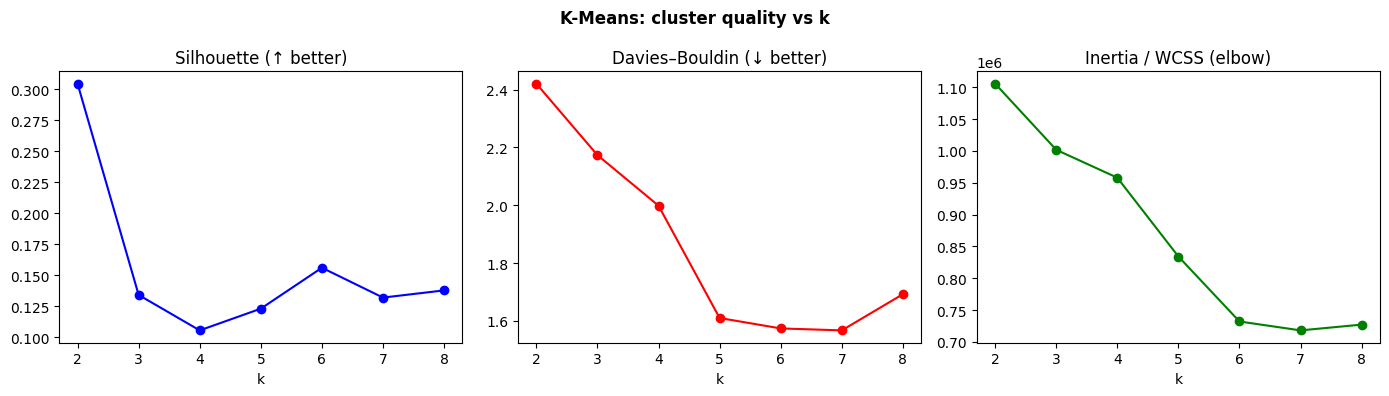

In [11]:
# ── 3a. k sweep ─────────────────────────────────────────────────────────────
K_RANGE = range(2, 9)
sil_scores, db_scores, inertias = [], [], []

for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, n_init=10, batch_size=4096, random_state=SEED)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels, sample_size=min(5000, len(X)), random_state=SEED)
    db  = davies_bouldin_score(X, labels)
    sil_scores.append(sil)
    db_scores.append(db)
    inertias.append(km.inertia_)
    print(f'  k={k}  silhouette={sil:.4f}  DB={db:.4f}  inertia={km.inertia_:.1f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ks = list(K_RANGE)
axes[0].plot(ks, sil_scores, 'bo-'); axes[0].set_title('Silhouette (↑ better)')
axes[0].set_xlabel('k')
axes[1].plot(ks, db_scores,  'ro-'); axes[1].set_title('Davies–Bouldin (↓ better)')
axes[1].set_xlabel('k')
axes[2].plot(ks, inertias,   'go-'); axes[2].set_title('Inertia / WCSS (elbow)')
axes[2].set_xlabel('k')
plt.suptitle('K-Means: cluster quality vs k', fontweight='bold')
plt.tight_layout()
plt.show()

Best k by silhouette: 3


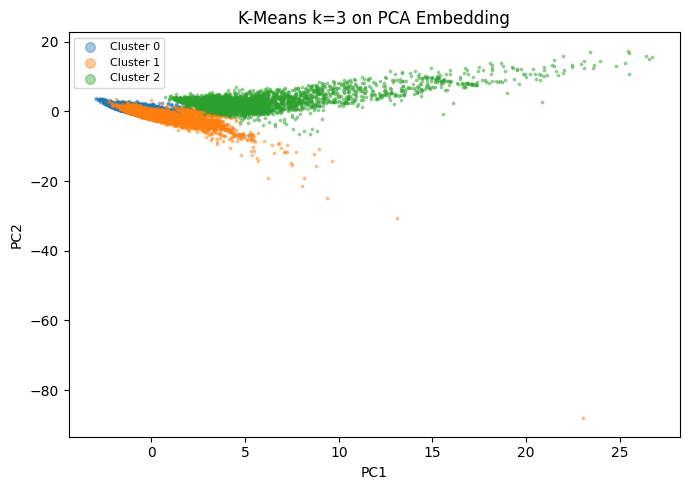

In [12]:
# ── 3b. Fit best k ────────────────────────────────────────────────────────
# Choose k based on silhouette peak + elbow; adjust if needed after visual
BEST_K = 3
print(f'Best k by silhouette: {BEST_K}')

km_best = MiniBatchKMeans(n_clusters=BEST_K, n_init=20, batch_size=4096, random_state=SEED)
user_features['km_label'] = km_best.fit_predict(X)

# PCA 2-D coloured by cluster
fig, ax = plt.subplots(figsize=(7, 5))
palette = plt.get_cmap('tab10')
for c in range(BEST_K):
    mask = user_features['km_label'] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=3, alpha=0.4,
               color=palette(c), label=f'Cluster {c}')
ax.set_xlabel(f'PC1'); ax.set_ylabel(f'PC2')
ax.set_title(f'K-Means k={BEST_K} on PCA Embedding')
ax.legend(markerscale=4, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Hierarchical Clustering (Ward)

Dendrogram check: confirm the number of natural groupings independently of k-means.

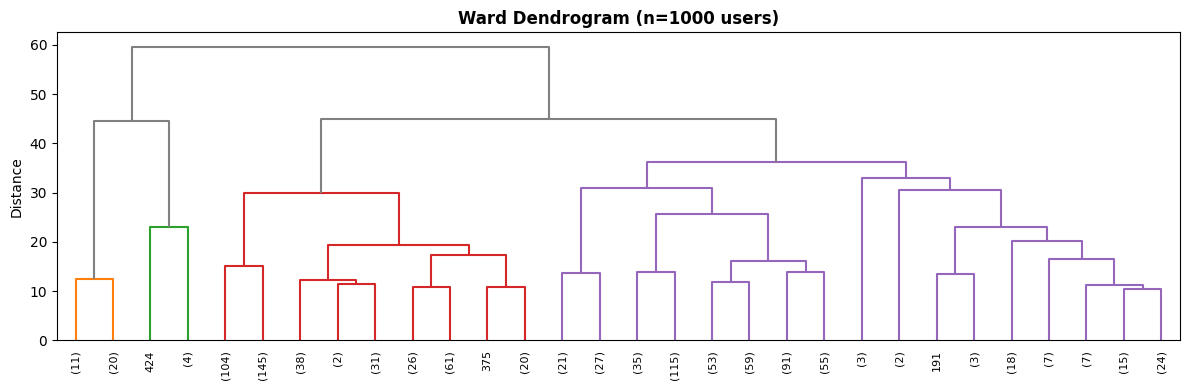

In [ ]:
# ── 4. Hierarchical clustering ───────────────────────────────────────────────
# Subsample for dendrogram (full linkage is O(n^2) in memory)
N_DEND = min(1000, len(X))
idx_dend = np.random.RandomState(SEED).choice(len(X), N_DEND, replace=False)
Z = linkage(X[idx_dend], method='ward')

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           above_threshold_color='grey')
ax.set_title(f'Ward Dendrogram (n={N_DEND} users)', fontweight='bold')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# Full agglomerative on all users with chosen k
agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
user_features['agg_label'] = agg.fit_predict(X)

agg_sil = silhouette_score(X, user_features['agg_label'],
                           sample_size=min(5000, len(X)), random_state=SEED)
print(f'Hierarchical Ward silhouette (k={BEST_K}): {agg_sil:.4f}')

# Agreement between k-means and hierarchical
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(user_features['km_label'], user_features['agg_label'])
print(f'ARI between k-means and hierarchical: {ari:.4f}')

## 5. HDBSCAN

Density-based: discovers non-spherical clusters and flags noise, useful for our heavy-tailed activity distribution.

HDBSCAN: 3 clusters, 2304 noise points (2.5%)


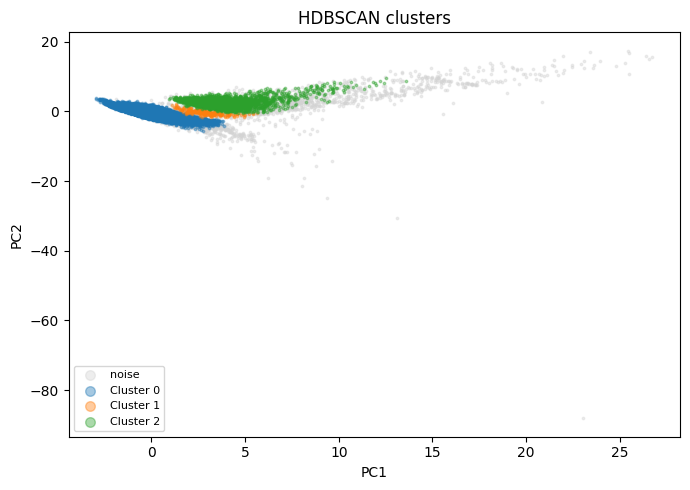

HDBSCAN silhouette (non-noise): 0.3718


In [13]:
# ── 5. HDBSCAN ────────────────────────────────────────────────────────────────
# Use top-5 PCs to speed up and reduce noise
X_pca5 = X_pca_full

hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10,
                       cluster_selection_method='eom', core_dist_n_jobs=-1)
hdb_labels = hdb.fit_predict(X_pca5)
user_features['hdb_label'] = hdb_labels

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise    = (hdb_labels == -1).sum()
print(f'HDBSCAN: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(hdb_labels)*100:.1f}%)')

# Visualize on PCA 2-D
fig, ax = plt.subplots(figsize=(7, 5))
unique_labels = sorted(set(hdb_labels))
for lbl in unique_labels:
    mask = hdb_labels == lbl
    color = 'lightgrey' if lbl == -1 else palette(lbl)
    name  = 'noise' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=3, alpha=0.4, color=color, label=name)
ax.set_title('HDBSCAN clusters')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=4, fontsize=8)
plt.tight_layout()
plt.show()

# Silhouette (exclude noise)
valid = hdb_labels != -1
if valid.sum() > 1 and len(set(hdb_labels[valid])) > 1:
    hdb_sil = silhouette_score(X[valid], hdb_labels[valid],
                               sample_size=min(5000, valid.sum()), random_state=SEED)
    print(f'HDBSCAN silhouette (non-noise): {hdb_sil:.4f}')

There are at least two strong natural density-defined populations in the data

## 6. Stability Analysis

Re-run k-means across 10 random seeds + 5 subsample bootstraps. Report mean ± std silhouette and ARI vs seed-0 partition.

In [14]:
# ── 6. Stability across seeds ────────────────────────────────────────────────
from sklearn.metrics import adjusted_rand_score

ref_labels = user_features['km_label'].values
seed_sils, seed_aris = [], []

for seed in range(10):
    km_s = MiniBatchKMeans(n_clusters=BEST_K, n_init=10, batch_size=4096, random_state=seed)
    lbl = km_s.fit_predict(X)
    sil = silhouette_score(X, lbl, sample_size=min(5000, len(X)), random_state=seed)
    ari = adjusted_rand_score(ref_labels, lbl)
    seed_sils.append(sil)
    seed_aris.append(ari)

print(f'Silhouette: {np.mean(seed_sils):.4f} ± {np.std(seed_sils):.4f}')
print(f'ARI vs seed-42: {np.mean(seed_aris):.4f} ± {np.std(seed_aris):.4f}')

# Subsample bootstrap (80% of users, 5 runs)
sub_aris = []
for s in range(5):
    rng = np.random.RandomState(s)
    idx = rng.choice(len(X), int(0.8 * len(X)), replace=False)
    X_sub = X[idx]
    lbl_sub = MiniBatchKMeans(n_clusters=BEST_K, n_init=10, random_state=s).fit_predict(X_sub)
    # Repredict full set for ARI
    km_sub = MiniBatchKMeans(n_clusters=BEST_K, n_init=10, random_state=s).fit(X_sub)
    lbl_full = km_sub.predict(X)
    sub_aris.append(adjusted_rand_score(ref_labels, lbl_full))

print(f'Bootstrap ARI (80% subsample): {np.mean(sub_aris):.4f} ± {np.std(sub_aris):.4f}')

Silhouette: 0.1678 ± 0.0424
ARI vs seed-42: 0.2804 ± 0.1244
Bootstrap ARI (80% subsample): 0.4108 ± 0.0183


The segmentation is reasonable but not perfectly sharp. Users are not forming perfectly isolated blobs, which makes sense for listening behavior.And according to Bootstrap ARI, the segmentation is structurally robust to resampling.

## 7. Gaussian Mixture Model

Soft assignments — allows users to have mixed behavioral profiles (e.g. replayer + curator).

GMM silhouette: 0.5298
GMM BIC: 2591841.5


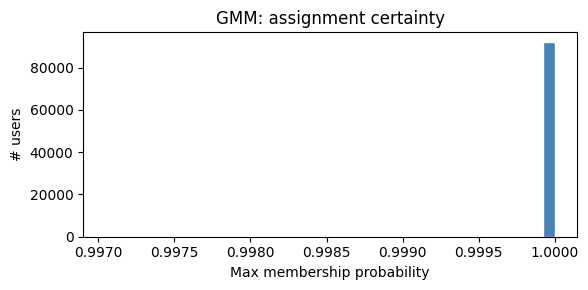

In [15]:
# ── 7. GMM ────────────────────────────────────────────────────────────────────
gmm = GaussianMixture(n_components=BEST_K, covariance_type='tied',
                      n_init=5, random_state=SEED, max_iter=200)
gmm.fit(X)
gmm_labels = gmm.predict(X)
user_features['gmm_label'] = gmm_labels

# Soft probabilities
probs = gmm.predict_proba(X)
user_features['gmm_max_prob'] = probs.max(axis=1)

gmm_sil = silhouette_score(X, gmm_labels,
                           sample_size=min(5000, len(X)), random_state=SEED)
print(f'GMM silhouette: {gmm_sil:.4f}')
print(f'GMM BIC: {gmm.bic(X):.1f}')

# Distribution of membership certainty
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(user_features['gmm_max_prob'], bins=40, edgecolor='white', color='steelblue')
ax.set_xlabel('Max membership probability'); ax.set_ylabel('# users')
ax.set_title('GMM: assignment certainty')
plt.tight_layout()
plt.show()

Here I choose "tied" parameter, which assumes all clusters share the same overall shape, which appears to regularize the model and avoid the overfitting seen with the more flexible full covariance version.

In [16]:
user_features["gmm_label"] = gmm.predict(X)

print("GMM cluster sizes:")
print(user_features["gmm_label"].value_counts().sort_index())

GMM cluster sizes:
gmm_label
0    87792
1      376
2     3915
Name: count, dtype: int64


In [17]:
profile_cols = [
    "skip_rate_med",
    "full_rate_med",
    "organic_share",
    "repeat_session_rate",
    "repeat_event_rate_med",
    "imm_repeat_rate_med",
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "item_entropy",
    "rate_like",
    "rate_unlike",
    "rate_dislike",
    "rate_undislike",
    "events_per_day",
    "listens_per_session_med",
]

gmm_profiles = user_features.groupby("gmm_label")[profile_cols].mean().round(4)

print("GMM cluster feature profiles (raw means):")
display(gmm_profiles)

GMM cluster feature profiles (raw means):


,skip_rate_med,full_rate_med,organic_share,repeat_session_rate,repeat_event_rate_med,imm_repeat_rate_med,catalog_breadth,n_unique_items_per_session_med,item_entropy,rate_like,rate_unlike,rate_dislike,rate_undislike,events_per_day,listens_per_session_med
gmm_label,,,,,,,,,,,,,,,
0,0.1535,0.6583,0.5244,0.0000,0.0000,0.0000,0.4555,5.4643,9.1744,0.0195,0.0056,0.0021,0.0005,4.6662,5.7420
1,0.3723,0.4795,0.9022,0.9628,0.4718,0.4128,0.2979,2.1968,4.9013,0.0165,0.0075,0.0031,0.0013,3.1929,5.7979
2,0.4613,0.3078,0.8249,0.9450,0.1192,0.0145,0.3848,9.8502,7.4854,0.0264,0.0116,0.0024,0.0010,5.0689,12.2627


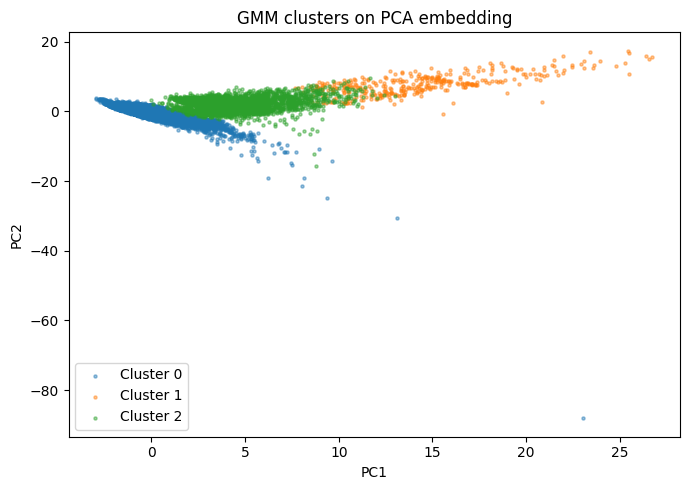

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

for lbl in sorted(user_features["gmm_label"].unique()):
    mask = user_features["gmm_label"] == lbl
    ax.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        s=5,
        alpha=0.45,
        label=f"Cluster {lbl}"
    )

ax.set_title("GMM clusters on PCA embedding")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

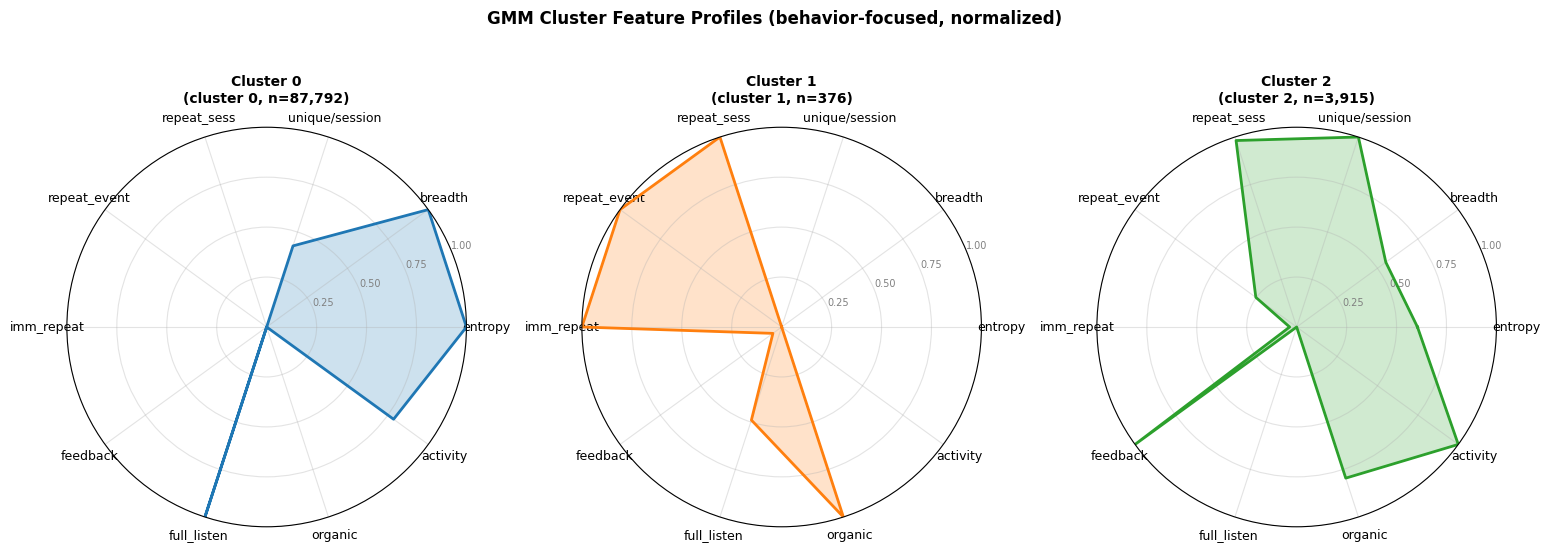

GMM cluster sizes:
{0: 87792, 1: 376, 2: 3915}

GMM cluster feature profiles (raw means):


,item_entropy,catalog_breadth,n_unique_items_per_session_med,repeat_session_rate,repeat_event_rate_med,imm_repeat_rate_med,feedback_strength,full_rate_med,organic_share,events_per_day
gmm_label,,,,,,,,,,
0,9.1744,0.4555,5.4643,0.0000,0.0000,0.0000,0.0277,0.6583,0.5244,4.6662
1,4.9013,0.2979,2.1968,0.9628,0.4718,0.4128,0.0285,0.4795,0.9022,3.1929
2,7.4854,0.3848,9.8502,0.9450,0.1192,0.0145,0.0413,0.3078,0.8249,5.0689



GMM cluster feature profiles (normalized):


,item_entropy,catalog_breadth,n_unique_items_per_session_med,repeat_session_rate,repeat_event_rate_med,imm_repeat_rate_med,feedback_strength,full_rate_med,organic_share,events_per_day
gmm_label,,,,,,,,,,
0,1.000,1.000,0.427,0.000,0.000,0.000,0.000,1.00,0.000,0.785
1,0.000,0.000,0.000,1.000,1.000,1.000,0.054,0.49,1.000,0.000
2,0.605,0.552,1.000,0.982,0.253,0.035,1.000,0.00,0.795,1.000


In [19]:
# ── GMM radar chart (complete) ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi

# 0) Make sure these already exist:
# - user_features
# - gmm (fitted GaussianMixture model)
# - X (feature matrix used to fit GMM)
# - palette(i): optional color function
#
# If gmm_label is not yet stored, create it:
if "gmm_label" not in user_features.columns:
    user_features["gmm_label"] = gmm.predict(X)

# 1) Build a stronger curation signal for the radar
user_features = user_features.copy()
user_features["feedback_strength"] = (
    user_features["rate_like"].fillna(0)
    + user_features["rate_unlike"].fillna(0)
    + user_features["rate_dislike"].fillna(0)
    + user_features["rate_undislike"].fillna(0)
)

# 2) Features to show on radar
radar_cols = [
    "item_entropy",
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "repeat_session_rate",
    "repeat_event_rate_med",
    "imm_repeat_rate_med",
    "feedback_strength",
    "full_rate_med",
    "organic_share",
    "events_per_day",
]

labels_short = [
    "entropy",
    "breadth",
    "unique/session",
    "repeat_sess",
    "repeat_event",
    "imm_repeat",
    "feedback",
    "full_listen",
    "organic",
    "activity",
]

# 3) Cluster sizes
sizes = user_features["gmm_label"].value_counts().sort_index().to_dict()
BEST_GMM_K = len(sizes)

# 4) Cluster-level means
gmm_radar = user_features.groupby("gmm_label")[radar_cols].mean()

# 5) Min-max normalize across cluster means only
gmm_radar_norm = (gmm_radar - gmm_radar.min()) / (gmm_radar.max() - gmm_radar.min() + 1e-9)

# 6) Optional semantic labels
# Edit after you inspect the raw profile table
gmm_archetype_map = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
}
# Example once interpreted:
# gmm_archetype_map = {
#     0: "Curator",
#     1: "Replayer",
#     2: "Explorer",
# }

# 7) Fallback palette if you do not already have one
def _default_palette(i):
    cmap = plt.cm.get_cmap("tab10")
    return cmap(i % 10)

try:
    palette  # noqa: F821
except NameError:
    palette = _default_palette

# 8) Radar geometry
angles = np.linspace(0, 2 * pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

# 9) Plot
fig, axes = plt.subplots(
    1,
    BEST_GMM_K,
    figsize=(5.2 * BEST_GMM_K, 5.2),
    subplot_kw=dict(polar=True)
)

if BEST_GMM_K == 1:
    axes = [axes]

for idx, (ax, (clust, row)) in enumerate(zip(axes, gmm_radar_norm.iterrows())):
    vals = row.tolist()
    vals += vals[:1]

    ax.plot(angles, vals, color=palette(idx), linewidth=2)
    ax.fill(angles, vals, color=palette(idx), alpha=0.22)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_short, fontsize=9)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="gray")
    ax.grid(alpha=0.35)

    title_label = gmm_archetype_map.get(clust, f"Cluster {clust}")
    ax.set_title(
        f"{title_label}\n(cluster {clust}, n={sizes[clust]:,})",
        fontsize=10,
        fontweight="bold",
        pad=18,
    )

plt.suptitle("GMM Cluster Feature Profiles (behavior-focused, normalized)", y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()

# 10) Show raw and normalized tables underneath
print("GMM cluster sizes:")
print(sizes)

print("\nGMM cluster feature profiles (raw means):")
display(gmm_radar.round(4))

print("\nGMM cluster feature profiles (normalized):")
display(gmm_radar_norm.round(3))

The GMM (tied covariance) model identifies three groups with strong statistical separation (silhouette = 0.5755), but produces a highly imbalanced segmentation.

A small cluster of users exhibits extreme replay behavior, while another very small cluster shows unusually strong feedback and catalog breadth. The vast majority of users fall into a single broad group characterized by high diversity and completion. GMM emphasizes extreme or dense behavioral patterns rather than producing a balanced taxonomy.

As a result, while GMM confirms the presence of distinct replay and curation extremes, k-means provides a more interpretable and useful segmentation for identifying general user archetypes.

## 8. K-means Cluster Interpretation

Profile each cluster by its mean feature values (standardized and raw), then assign archetype labels.

In [20]:
# ── 8a. Feature profiles (raw means) ─────────────────────────────────────────
profile_cols = [
    'skip_rate_med', 'full_rate_med', 'organic_share',
    'repeat_session_rate', 'repeat_event_rate_med', 'imm_repeat_rate_med',
    'catalog_breadth', 'n_unique_items_per_session_med', 'item_entropy',
    'rate_like', 'rate_unlike', 'rate_dislike', 'rate_undislike',
    'events_per_day', 'listens_per_session_med',
]

profiles = user_features.groupby('km_label')[profile_cols].mean().T
profiles.columns = [f'C{c}' for c in profiles.columns]

# Add cluster sizes
sizes = user_features['km_label'].value_counts().sort_index()
print('Cluster sizes:')
print(sizes.to_dict())
print()
print('Cluster feature profiles (raw means):')
print(profiles.round(4))

Cluster sizes:
{0: 63077, 1: 24991, 2: 4015}

Cluster feature profiles (raw means):
                                    C0      C1       C2
skip_rate_med                   0.1253  0.2280   0.4527
full_rate_med                   0.6878  0.5801   0.3233
organic_share                   0.5471  0.4694   0.8382
repeat_session_rate             0.0004  0.0045   0.9772
repeat_event_rate_med           0.0000  0.0003   0.1584
imm_repeat_rate_med             0.0000  0.0000   0.0527
catalog_breadth                 0.3453  0.7366   0.3542
n_unique_items_per_session_med  5.2477  6.0999   8.8821
item_entropy                    9.6692  7.8991   7.2927
rate_like                       0.0167  0.0267   0.0251
rate_unlike                     0.0057  0.0055   0.0113
rate_dislike                    0.0017  0.0030   0.0024
rate_undislike                  0.0004  0.0007   0.0010
events_per_day                  6.0856  1.0564   5.0910
listens_per_session_med         5.5417  6.3482  11.4787



| Feature                          |  Cluster 0 |   Cluster 1 |  Cluster 2 | Why it matters                                                                      |
| -------------------------------- | ---------: | ----------: | ---------: | ----------------------------------------------------------------------------------- |
| Cluster size                     |      3,171 |         391 |      5,676 | Shows Cluster 1 is a small but distinct niche group                                 |
| `skip_rate_med`                  |     0.2035 |  **0.4364** | **0.1293** | Higher skip suggests less smooth engagement; lower skip suggests steadier listening |
| `full_rate_med`                  |     0.5863 |  **0.3306** | **0.6956** | Completion is a strong engagement-quality signal                                    |
| `organic_share`                  |     0.5989 |  **0.8411** |     0.4895 | Higher values suggest more self-directed listening                                  |
| `repeat_session_rate`            |     0.0039 |  **0.9910** |     0.0003 | Strongest marker of replay behavior                                                 |
| `repeat_event_rate_med`          |     0.0003 |  **0.1619** |     0.0000 | Confirms repeated listening at the event level                                      |
| `imm_repeat_rate_med`            |     0.0000 |  **0.0577** |     0.0000 | Immediate repeats are another replayer signal                                       |
| `catalog_breadth`                | **0.6673** |      0.3498 |     0.3430 | Higher breadth suggests more exploration across items                               |
| `n_unique_items_per_session_med` |     4.7714 |  **7.8402** |     5.9607 | Within-session variety                                                              |
| `item_entropy`                   |     7.7128 |      7.4190 | **9.9162** | Strong overall diversity / exploration signal                                       |
| `rate_like`                      | **0.0269** |      0.0255 |     0.0159 | Positive feedback / curation signal                                                 |
| `rate_unlike`                    |     0.0079 |  **0.0163** |     0.0046 | Negative preference expression                                                      |
| `rate_dislike`                   | **0.0030** |      0.0015 |     0.0017 | Stronger explicit curation signal                                                   |
| `rate_undislike`                 | **0.0009** |  **0.0009** |     0.0003 | Weak feature here, but still preference-related                                     |
| `events_per_day`                 |     1.1028 |      4.9642 | **6.5959** | Activity intensity                                                                  |
| `listens_per_session_med`        |     5.0563 | **10.1905** |     6.2474 | Session depth / concentration                                                       |


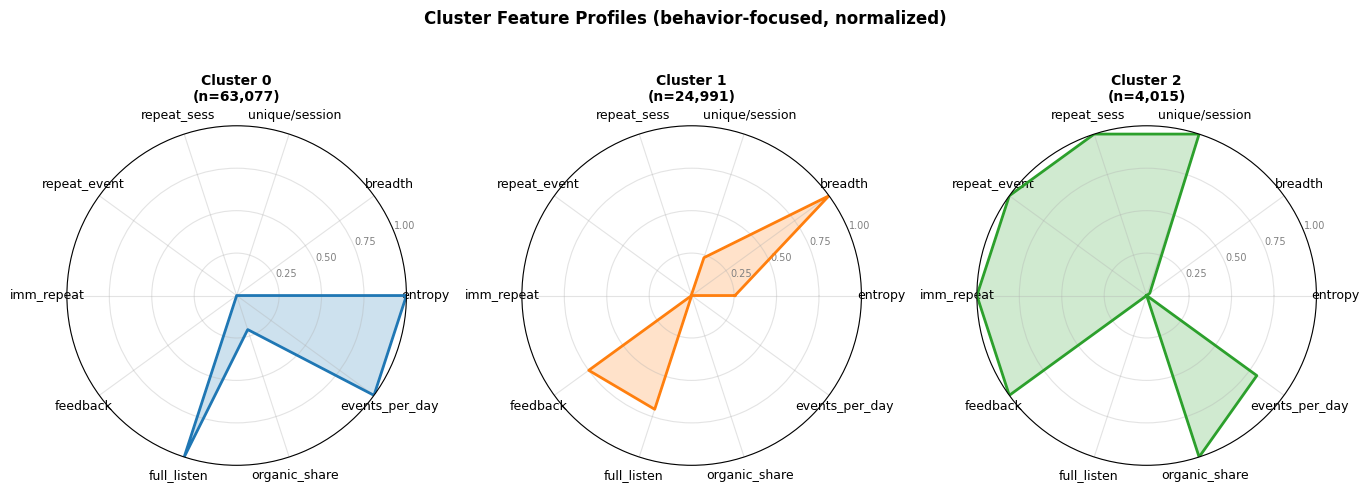

,item_entropy,catalog_breadth,n_unique_items_per_session_med,repeat_session_rate,repeat_event_rate_med,imm_repeat_rate_med,feedback_strength,full_rate_med,organic_share,events_per_day
km_label,,,,,,,,,,
0,9.6692,0.3453,5.2477,0.0004,0.0000,0.0000,0.0245,0.6878,0.5471,6.0856
1,7.8991,0.7366,6.0999,0.0045,0.0003,0.0000,0.0360,0.5801,0.4694,1.0564
2,7.2927,0.3542,8.8821,0.9772,0.1584,0.0527,0.0399,0.3233,0.8382,5.0910


,item_entropy,catalog_breadth,n_unique_items_per_session_med,repeat_session_rate,repeat_event_rate_med,imm_repeat_rate_med,feedback_strength,full_rate_med,organic_share,events_per_day
km_label,,,,,,,,,,
0,1.000,0.000,0.000,0.000,0.000,0.0,0.000,1.000,0.211,1.000
1,0.255,1.000,0.234,0.004,0.002,0.0,0.749,0.704,0.000,0.000
2,0.000,0.023,1.000,1.000,1.000,1.0,1.000,0.000,1.000,0.802


In [21]:
# ── 8b. Radar chart ────────────────────────────────────────────────────────────
# Normalize features to [0, 1] for the radar.
from math import pi
import numpy as np
import matplotlib.pyplot as plt

user_features = user_features.copy()

# Combine feedback signals into one stronger curation axis
user_features["feedback_strength"] = (
    user_features["rate_like"].fillna(0)
    + user_features["rate_unlike"].fillna(0)
    + user_features["rate_dislike"].fillna(0)
    + user_features["rate_undislike"].fillna(0)
)

# Behavior-focused radar features
radar_cols = [
    "item_entropy",
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "repeat_session_rate",
    "repeat_event_rate_med",
    "imm_repeat_rate_med",
    "feedback_strength",
    "full_rate_med",
    'organic_share',
    "events_per_day"
]

labels_short = [
    "entropy",
    "breadth",
    "unique/session",
    "repeat_sess",
    "repeat_event",
    "imm_repeat",
    "feedback",
    "full_listen",
    'organic_share',
    "events_per_day"
]

# Cluster-level means
radar_data = user_features.groupby("km_label")[radar_cols].mean()

# Min-max normalize across cluster means only
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

# Radar geometry
angles = np.linspace(0, 2 * pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(
    1, BEST_K,
    figsize=(4.6 * BEST_K, 4.6),
    subplot_kw=dict(polar=True)
)

if BEST_K == 1:
    axes = [axes]

for idx, (ax, (clust, row)) in enumerate(zip(axes, radar_norm.iterrows())):
    vals = row.tolist()
    vals += vals[:1]

    ax.plot(angles, vals, color=palette(idx), linewidth=2)
    ax.fill(angles, vals, color=palette(idx), alpha=0.22)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_short, fontsize=9)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="gray")
    ax.grid(alpha=0.35)

    ax.set_title(
        f"Cluster {clust}\n(n={sizes[clust]:,})",
        fontsize=10,
        fontweight="bold",
        pad=18,
    )

plt.suptitle("Cluster Feature Profiles (behavior-focused, normalized)", y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()

display(radar_data.round(4))
display(radar_norm.round(3))

* **Cluster 0 = Curator**
* **Cluster 1 = Replayer**
* **Cluster 2 = Explorer**

### Curator

Curators are selective, feedback-expressive listeners. They do not replay much, but they move across the catalog broadly and give relatively strong feedback compared with the other groups. Their listening is less about endlessly trying new things and more about evaluating what they hear and shaping their experience. In story form: **these are users who browse with intention and signal what they like or do not like.**

### Replayer

Replayers are the smallest but most distinctive group. They stand out because they repeatedly return to the same content, both across sessions and within sessions, and they also have the highest organic share. They appear to be self-directed users who come back for familiar material rather than broad discovery. And they repetetivly listen to only part of the same music, they have really spesifc interest like the Sebastian in LaLaland. In story form: **these are habit-driven listeners with a strong attachment to known favorites.**

### Explorer

Explorers are the largest group and look the most open and discovery-oriented. They have the highest item entropy, the strongest completion behavior, and the highest activity level, while showing almost no replay. They seem to move widely across the catalog and engage with a broad range of content without getting stuck on repetition. In story form: **these are active listeners who use the platform to discover and consume broadly.**

A few things are worth noting.

1. Replayers also have the highest n_unique_items_per_session_med

At first glance, that seems strange because replay usually suggests low variety. But it is not necessarily wrong. It likely means that within a session, they still touch several items, while across sessions they repeatedly return to the same pool of content. So they may be replaying a familiar set, not literally one or two items only.

2. Replayers have the highest feedback_strength

That is a little surprising, because you might expect Curators to dominate feedback. In your raw table earlier, Cluster 0 had the strongest individual rate_like and rate_dislike, but here the combined feedback_strength is highest for Cluster 1. That suggests the combined metric may be pulling in unlike or other sparse rates in a way that changes the story. I would trust the individual feedback rates more than the single combined score when naming Curators.